## Type classification

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.2941 - 0.9591

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.6801 - 0.9706


/tmp/ipykernel_179739/3752189118.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


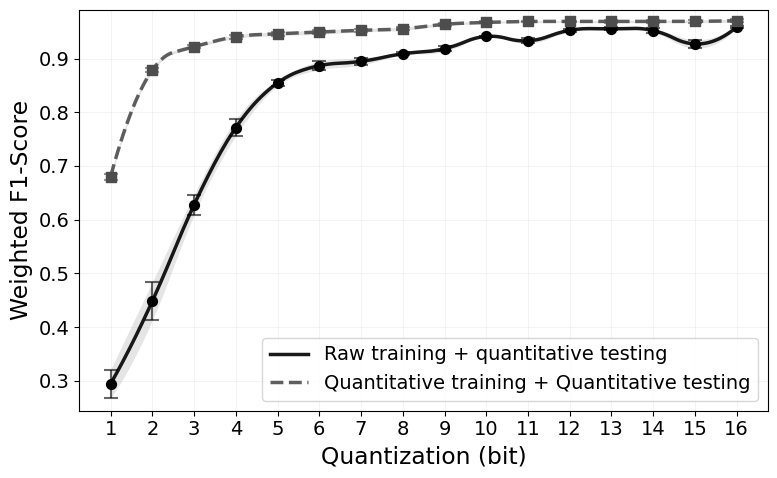


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.2941 ± 0.0267
b=2: 0.4483 ± 0.0356
b=3: 0.6276 ± 0.0191
b=4: 0.7715 ± 0.0152
b=5: 0.8548 ± 0.0060
b=6: 0.8869 ± 0.0078
b=7: 0.8949 ± 0.0067
b=8: 0.9090 ± 0.0025
b=9: 0.9185 ± 0.0048
b=10: 0.9414 ± 0.0014
b=11: 0.9332 ± 0.0047
b=12: 0.9528 ± 0.0032
b=13: 0.9556 ± 0.0026
b=14: 0.9523 ± 0.0039
b=15: 0.9274 ± 0.0080
b=16: 0.9591 ± 0.0023

Quantitative training + Quantitative testing：
b=1: 0.6801 ± 0.0057
b=2: 0.8788 ± 0.0036
b=3: 0.9223 ± 0.0027
b=4: 0.9408 ± 0.0033
b=5: 0.9463 ± 0.0033
b=6: 0.9495 ± 0.0038
b=7: 0.9528 ± 0.0032
b=8: 0.9557 ± 0.0030
b=9: 0.9639 ± 0.0025
b=10: 0.9675 ± 0.0019
b=11: 0.9692 ± 0.0018
b=12: 0.9693 ± 0.0016
b=13: 0.9692 ± 0.0019
b=14: 0.9694 ± 0.0022
b=15: 0.9695 ± 0.0026
b=16: 0.9706 ± 0.0028
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.1421 - 0.9240

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.3645 - 0.9475


/tmp/ipykernel_179739/3288753643.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


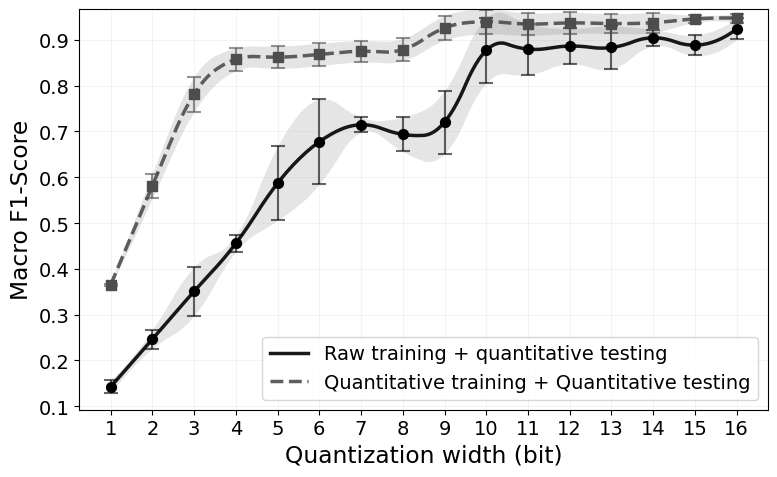


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.1421 ± 0.0141
b=2: 0.2461 ± 0.0206
b=3: 0.3506 ± 0.0531
b=4: 0.4555 ± 0.0180
b=5: 0.5868 ± 0.0809
b=6: 0.6775 ± 0.0926
b=7: 0.7146 ± 0.0164
b=8: 0.6936 ± 0.0373
b=9: 0.7204 ± 0.0688
b=10: 0.8771 ± 0.0712
b=11: 0.8800 ± 0.0558
b=12: 0.8865 ± 0.0387
b=13: 0.8834 ± 0.0465
b=14: 0.9046 ± 0.0178
b=15: 0.8885 ± 0.0225
b=16: 0.9240 ± 0.0229

Quantitative training + Quantitative testing：
b=1: 0.3645 ± 0.0025
b=2: 0.5810 ± 0.0271
b=3: 0.7814 ± 0.0381
b=4: 0.8575 ± 0.0247
b=5: 0.8623 ± 0.0242
b=6: 0.8682 ± 0.0244
b=7: 0.8751 ± 0.0234
b=8: 0.8789 ± 0.0242
b=9: 0.9259 ± 0.0268
b=10: 0.9397 ± 0.0267
b=11: 0.9347 ± 0.0244
b=12: 0.9371 ± 0.0232
b=13: 0.9357 ± 0.0217
b=14: 0.9376 ± 0.0215
b=15: 0.9458 ± 0.0079
b=16: 0.9475 ± 0.0095
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Macro F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

# Device Name

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.4407 - 0.9603

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.6273 - 0.9610


/tmp/ipykernel_179739/3341788551.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


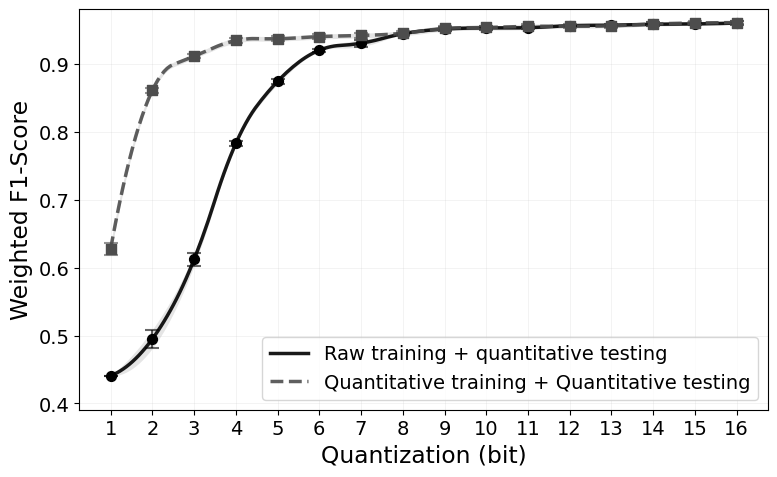


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.4407 ± 0.0004
b=2: 0.4949 ± 0.0138
b=3: 0.6120 ± 0.0091
b=4: 0.7829 ± 0.0037
b=5: 0.8744 ± 0.0041
b=6: 0.9203 ± 0.0022
b=7: 0.9306 ± 0.0050
b=8: 0.9445 ± 0.0014
b=9: 0.9515 ± 0.0024
b=10: 0.9532 ± 0.0033
b=11: 0.9535 ± 0.0026
b=12: 0.9564 ± 0.0016
b=13: 0.9572 ± 0.0024
b=14: 0.9585 ± 0.0028
b=15: 0.9590 ± 0.0019
b=16: 0.9603 ± 0.0024

Quantitative training + Quantitative testing：
b=1: 0.6273 ± 0.0085
b=2: 0.8611 ± 0.0042
b=3: 0.9115 ± 0.0034
b=4: 0.9346 ± 0.0038
b=5: 0.9372 ± 0.0033
b=6: 0.9403 ± 0.0037
b=7: 0.9420 ± 0.0034
b=8: 0.9452 ± 0.0037
b=9: 0.9523 ± 0.0038
b=10: 0.9538 ± 0.0021
b=11: 0.9554 ± 0.0035
b=12: 0.9555 ± 0.0029
b=13: 0.9562 ± 0.0028
b=14: 0.9589 ± 0.0027
b=15: 0.9604 ± 0.0024
b=16: 0.9610 ± 0.0025
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Weighted F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")

Parsed conditions:

Raw training + quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.1021 - 0.9278

Quantitative training + Quantitative testing:
  b values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Range: 0.3188 - 0.9269


/tmp/ipykernel_179739/173647803.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


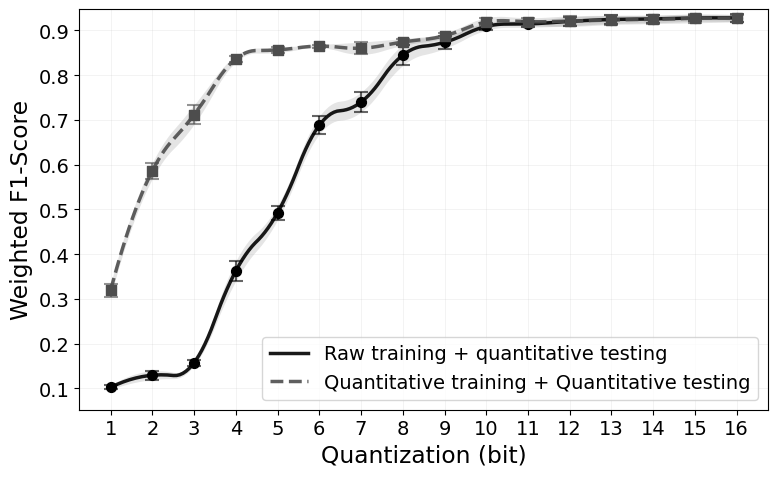


Figure generated successfully!
Saved as: figure_comparison.pdf and figure_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import re

# Reset to defaults and apply original styling parameters
mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})

# ============================================================
# PASTE YOUR DATA HERE (between the triple quotes)
# ============================================================
data_text = """
Raw training + quantitative testing:
b=1: 0.1021 ± 0.0045
b=2: 0.1292 ± 0.0098
b=3: 0.1572 ± 0.0068
b=4: 0.3623 ± 0.0223
b=5: 0.4923 ± 0.0161
b=6: 0.6879 ± 0.0200
b=7: 0.7397 ± 0.0222
b=8: 0.8445 ± 0.0229
b=9: 0.8733 ± 0.0139
b=10: 0.9088 ± 0.0085
b=11: 0.9145 ± 0.0074
b=12: 0.9201 ± 0.0098
b=13: 0.9243 ± 0.0090
b=14: 0.9256 ± 0.0084
b=15: 0.9277 ± 0.0075
b=16: 0.9278 ± 0.0083

Quantitative training + Quantitative testing：
b=1: 0.3188 ± 0.0138
b=2: 0.5861 ± 0.0176
b=3: 0.7116 ± 0.0215
b=4: 0.8364 ± 0.0071
b=5: 0.8564 ± 0.0059
b=6: 0.8648 ± 0.0035
b=7: 0.8602 ± 0.0137
b=8: 0.8740 ± 0.0076
b=9: 0.8880 ± 0.0060
b=10: 0.9185 ± 0.0097
b=11: 0.9195 ± 0.0089
b=12: 0.9207 ± 0.0116
b=13: 0.9233 ± 0.0103
b=14: 0.9246 ± 0.0094
b=15: 0.9269 ± 0.0099
b=16: 0.9268 ± 0.0078
"""
# ============================================================

def parse_data(text):
    """Parse the data format and extract b values, means, and stds for each condition"""
    conditions = {}
    
    # Normalize full-width colon to regular colon
    text = text.replace('：', ':')
    
    # Find all condition patterns with their data
    # Pattern: condition name followed by colon, then b=X: Y ± Z patterns
    condition_pattern = r'([^:]+?):\s*((?:b=\d+:\s*[\d.]+\s*±\s*[\d.]+\s*)+)'
    
    matches = re.finditer(condition_pattern, text)
    
    for match in matches:
        condition_name = match.group(1).strip()
        data_part = match.group(2).strip()
        
        # Find all b=X: Y ± Z patterns
        value_pattern = r'b=(\d+):\s*([\d.]+)\s*±\s*([\d.]+)'
        value_matches = re.findall(value_pattern, data_part)
        
        b_values = []
        means = []
        stds = []
        
        for value_match in value_matches:
            b_values.append(int(value_match[0]))
            means.append(float(value_match[1]))
            stds.append(float(value_match[2]))
        
        if b_values:  # Only add if we found data
            conditions[condition_name] = {
                'b': np.array(b_values),
                'mean': np.array(means),
                'std': np.array(stds)
            }
    
    return conditions

# Parse the data
conditions = parse_data(data_text)

# Print parsed data for verification
print("Parsed conditions:")
for cond_name, data in conditions.items():
    print(f"\n{cond_name}:")
    print(f"  b values: {data['b']}")
    print(f"  Range: {data['mean'].min():.4f} - {data['mean'].max():.4f}")

# Get the two conditions (assuming we have exactly 2)
cond_names = list(conditions.keys())
if len(cond_names) != 2:
    print(f"Warning: Expected 2 conditions, found {len(cond_names)}")

# Assign conditions
cond1_name = cond_names[0]
cond2_name = cond_names[1]

cond1 = conditions[cond1_name]
cond2 = conditions[cond2_name]

# Create interpolation functions for means
interp_cond1 = interp1d(cond1['b'], cond1['mean'], kind='quadratic')
interp_cond2 = interp1d(cond2['b'], cond2['mean'], kind='quadratic')

# Create interpolation functions for standard deviations
interp_cond1_std = interp1d(cond1['b'], cond1['std'], kind='quadratic')
interp_cond2_std = interp1d(cond2['b'], cond2['std'], kind='quadratic')

# Extended arrays for smooth visualization
b_smooth = np.linspace(cond1['b'].min(), cond1['b'].max(), 200)

# Interpolate smooth curves
cond1_smooth = interp_cond1(b_smooth)
cond2_smooth = interp_cond2(b_smooth)
cond1_std_smooth = interp_cond1_std(b_smooth)
cond2_std_smooth = interp_cond2_std(b_smooth)

# Professional black and white styling
color_cond1 = '#000000'      # Black
color_cond2 = '#4D4D4D'      # Dark gray
linestyle_cond1 = '-'        # Solid line
linestyle_cond2 = '--'       # Dashed line
marker_cond1 = 'o'           # Circle
marker_cond2 = 's'           # Square

# Create figure
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Plot Condition 1 with standard deviation band
ax.fill_between(b_smooth, 
                cond1_smooth - cond1_std_smooth,
                cond1_smooth + cond1_std_smooth,
                color=color_cond1, alpha=0.1, linewidth=0)
ax.plot(b_smooth, cond1_smooth, 
        color=color_cond1, linestyle=linestyle_cond1, linewidth=2.5,
        label=cond1_name, alpha=0.9)
ax.errorbar(cond1['b'], cond1['mean'], yerr=cond1['std'],
           fmt='none', ecolor=color_cond1, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond1['b'], cond1['mean'], 
          color=color_cond1, s=50, zorder=5, marker=marker_cond1)

# Plot Condition 2 with standard deviation band
ax.fill_between(b_smooth, 
                cond2_smooth - cond2_std_smooth,
                cond2_smooth + cond2_std_smooth,
                color=color_cond2, alpha=0.15, linewidth=0)
ax.plot(b_smooth, cond2_smooth, 
        color=color_cond2, linestyle=linestyle_cond2, linewidth=2.5,
        label=cond2_name, alpha=0.9)
ax.errorbar(cond2['b'], cond2['mean'], yerr=cond2['std'],
           fmt='none', ecolor=color_cond2, capsize=5, capthick=1.5, 
           alpha=0.6, linewidth=1.5)
ax.scatter(cond2['b'], cond2['mean'], 
          color=color_cond2, s=50, zorder=5, marker=marker_cond2)

# Customize figure
ax.set_xlabel('Quantization width (bit)', fontsize='large')
ax.set_ylabel('Macro F1-Score', fontsize='large')
ax.set_xticks(cond1['b'])
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.legend(loc='lower right', fontsize='medium',
         frameon=True,
         fancybox=True)

# Set y-axis limits with some padding
y_min = min(cond1['mean'].min(), cond2['mean'].min()) - 0.05
y_max = min(1.0, max(cond1['mean'].max(), cond2['mean'].max()) + 0.02)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('figure_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure generated successfully!")
print("Saved as: figure_comparison.pdf and figure_comparison.png")